# 1. Introduction

1. Введение
Примеры использования машинного обучения в жизни и их польза:

Рекомендательные системы в онлайн-магазинах и стриминговых сервисах — помогают подобрать товары, фильмы или музыку, исходя из предпочтений пользователя, что улучшает пользовательский опыт и увеличивает продажи.
Распознавание лиц и биометрия — используются для безопасности и идентификации, например, в смартфонах или системах контроля доступа, что повышает уровень защиты.
Автономные транспортные средства — машины могут самостоятельно ориентироваться на дороге, что делает передвижение безопаснее и удобнее.
Диагностика заболеваний по медицинским данным — помогает врачам быстрее и точнее ставить диагнозы, что способствует своевременному лечению и спасению жизней.
Обработка текста и переводчики — автоматический перевод текстов и голосовых команд облегчает коммуникацию между людьми и автоматизирует работу с информацией.

Категории задач (классификация или регрессия):

Рекомендательные системы — задачи регрессии или классификации в зависимости от подхода (например, предсказание оценки или категории товара).
Распознавание лиц — задача классификации (определение, кто изображен).
Автономные автомобили — задачи регрессии (предсказание траектории) и классификации (распознавание объектов).
Диагностика заболеваний — классификация (болезнь или нет).
Обработка текста — классификация (определение темы) или регрессия (оценка тональности).

Разница между мультиклассом и мультилейблом:

Мультикласс — задача, в которой каждый объект относится к одному из нескольких классов. Например, определить, к какой породе собаки принадлежит изображение (породы: лабрадор, хаски, пудель).
Мультилейбл — задача, в которой один объект может принадлежать нескольким классам одновременно. Например, для мультимедийных тегов: изображение может одновременно содержать "пляж", "закат" и "люди".

Задача предсказания цены дома:
Это задача регрессии, потому что мы предсказываем числовое значение — цену в денежном выражении. Можно ли свести регрессию к классификации? Теоретически — да, можно разбить диапазон цен на категории (например, низкая, средняя, высокая), и тогда это станет задачей классификации. Но при этом мы теряем точность и детализацию, потому что вместо точной цены предсказываем лишь категорию.

# 2. Introduction to Data Analysis

In [264]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import scipy
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor

In [265]:
df = pd.read_json("train.json")

In [266]:
df

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


49352 rows, 15 columns

In [267]:
print(df.columns)

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='str')


target = price

In [268]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB
None


In [269]:
print(df.describe())

         bathrooms      bedrooms      latitude    listing_id     longitude  \
count  49352.00000  49352.000000  49352.000000  4.935200e+04  49352.000000   
mean       1.21218      1.541640     40.741545  7.024055e+06    -73.955716   
std        0.50142      1.115018      0.638535  1.262746e+05      1.177912   
min        0.00000      0.000000      0.000000  6.811957e+06   -118.271000   
25%        1.00000      1.000000     40.728300  6.915888e+06    -73.991700   
50%        1.00000      1.000000     40.751800  7.021070e+06    -73.977900   
75%        1.00000      2.000000     40.774300  7.128733e+06    -73.954800   
max       10.00000      8.000000     44.883500  7.753784e+06      0.000000   

              price  
count  4.935200e+04  
mean   3.830174e+03  
std    2.206687e+04  
min    4.300000e+01  
25%    2.500000e+03  
50%    3.150000e+03  
75%    4.100000e+03  
max    4.490000e+06  


In [270]:
# Выберите только числовые колонки
numeric_df = df.select_dtypes(include=['number'])

# Теперь посчитайте корреляцию
print(numeric_df.corr())

            bathrooms  bedrooms  latitude  listing_id  longitude     price
bathrooms    1.000000  0.533446 -0.009657    0.000776   0.010393  0.069661
bedrooms     0.533446  1.000000 -0.004745    0.011968   0.006892  0.051788
latitude    -0.009657 -0.004745  1.000000    0.001712  -0.966807 -0.000707
listing_id   0.000776  0.011968  0.001712    1.000000  -0.000907  0.008090
longitude    0.010393  0.006892 -0.966807   -0.000907   1.000000 -0.000087
price        0.069661  0.051788 -0.000707    0.008090  -0.000087  1.000000


In [271]:
print(df.isnull().sum())

bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
interest_level     0
dtype: int64


0 empty columns(nums), some columns don't make enough sence 

working df

In [272]:
df_selected = df[["price", "bathrooms", "bedrooms", "interest_level"]]
df_selected

,price,bathrooms,bedrooms,interest_level
4,2400,1.0,1,medium
6,3800,1.0,2,low
9,3495,1.0,2,medium
10,3000,1.5,3,medium
15,2795,1.0,0,low
...,...,...,...,...
124000,2800,1.0,3,low
124002,2395,1.0,2,medium
124004,1850,1.0,1,medium
124008,4195,1.0,2,medium


In [273]:
df_selected["bathrooms"].dtype

dtype('float64')

# 3. Statistical Data Analysis

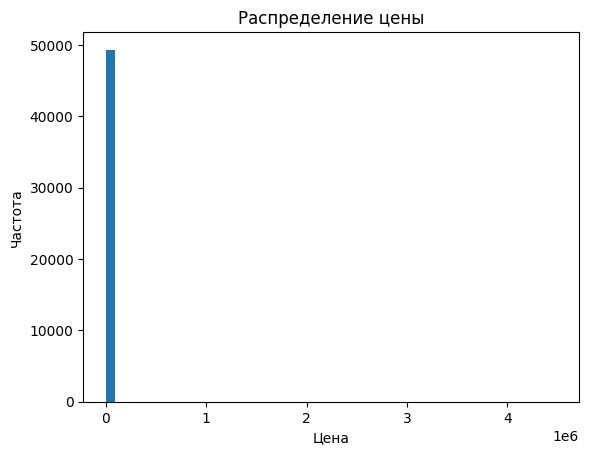

In [274]:
plt.hist(df_selected['price'], bins=50)
plt.title('Распределение цены')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

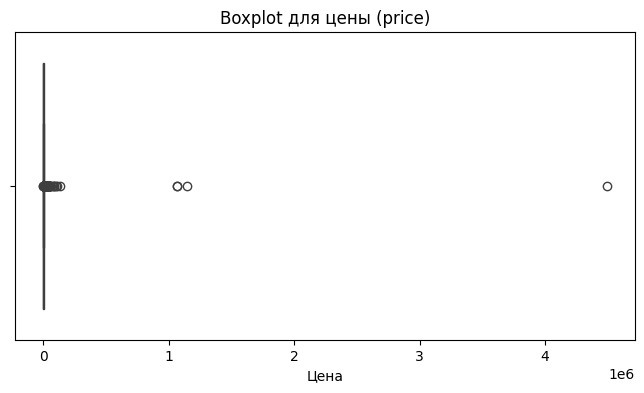

In [275]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_selected['price'])
plt.title('Boxplot для цены (price)')
plt.xlabel('Цена')
plt.show()

delete rows

In [276]:
# Вычисляем 1-й и 99-й процентиль
lower_bound = df_selected['price'].quantile(0.01)
upper_bound = df_selected['price'].quantile(0.99)

# Оставляем только строки, где значение в диапазоне между этими границами
df_selected = df_selected[(df_selected['price'] >= lower_bound) & (df_selected['price'] <= upper_bound)]
df_selected

,price,bathrooms,bedrooms,interest_level
4,2400,1.0,1,medium
6,3800,1.0,2,low
9,3495,1.0,2,medium
10,3000,1.5,3,medium
15,2795,1.0,0,low
...,...,...,...,...
124000,2800,1.0,3,low
124002,2395,1.0,2,medium
124004,1850,1.0,1,medium
124008,4195,1.0,2,medium


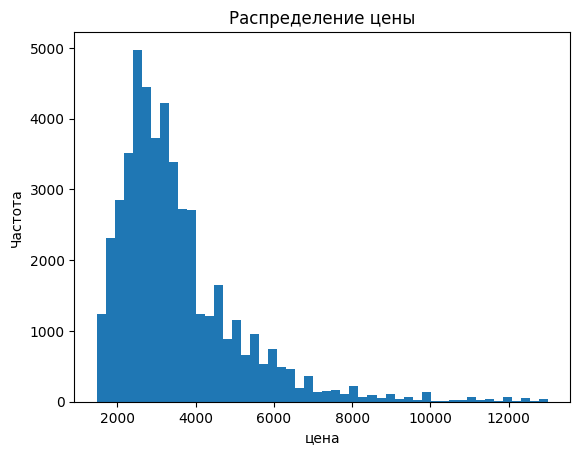

In [277]:
plt.hist(df_selected['price'], bins=50)
plt.title('Распределение цены')
plt.xlabel('цена')
plt.ylabel('Частота')
plt.show()

Now we can see some result

In [278]:
print(df_selected["interest_level"].dtype)

str


In [279]:
df_selected["interest_level"]

4         medium
6            low
9         medium
10        medium
15           low
           ...  
124000       low
124002    medium
124004    medium
124008    medium
124009      high
Name: interest_level, Length: 48379, dtype: str

In [280]:
# Выводит все уникальные значения и количество их появлений
print(df_selected['interest_level'].value_counts())

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64


In [281]:
df_selected['interest_level'] = df_selected['interest_level'].apply(lambda x: 0 if x == 'low' else (1 if x == 'medium' else 2))
df_selected

,price,bathrooms,bedrooms,interest_level
4,2400,1.0,1,1
6,3800,1.0,2,0
9,3495,1.0,2,1
10,3000,1.5,3,1
15,2795,1.0,0,0
...,...,...,...,...
124000,2800,1.0,3,0
124002,2395,1.0,2,1
124004,1850,1.0,1,1
124008,4195,1.0,2,1


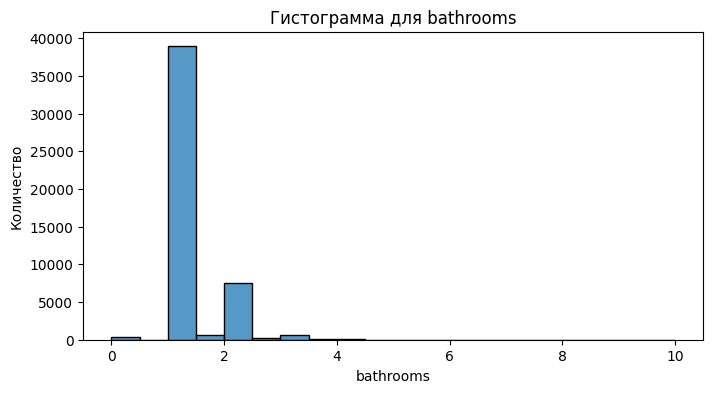

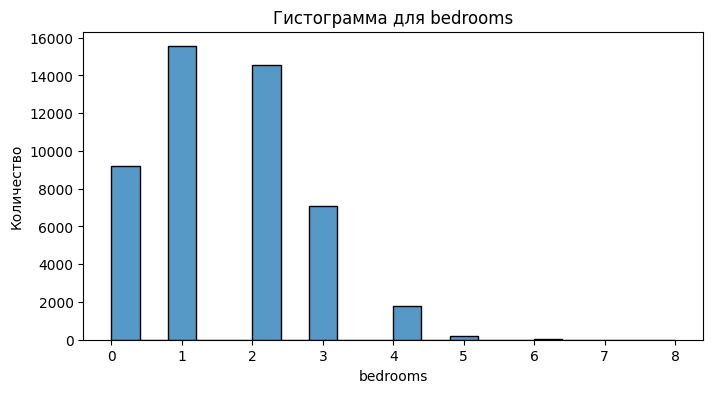

In [282]:
features = ['bathrooms', 'bedrooms']

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_selected[feature], bins=20, kde=False)
    plt.title(f'Гистограмма для {feature}')
    plt.xlabel(feature)
    plt.ylabel('Количество')
    plt.show()

no outliders

corr matrix

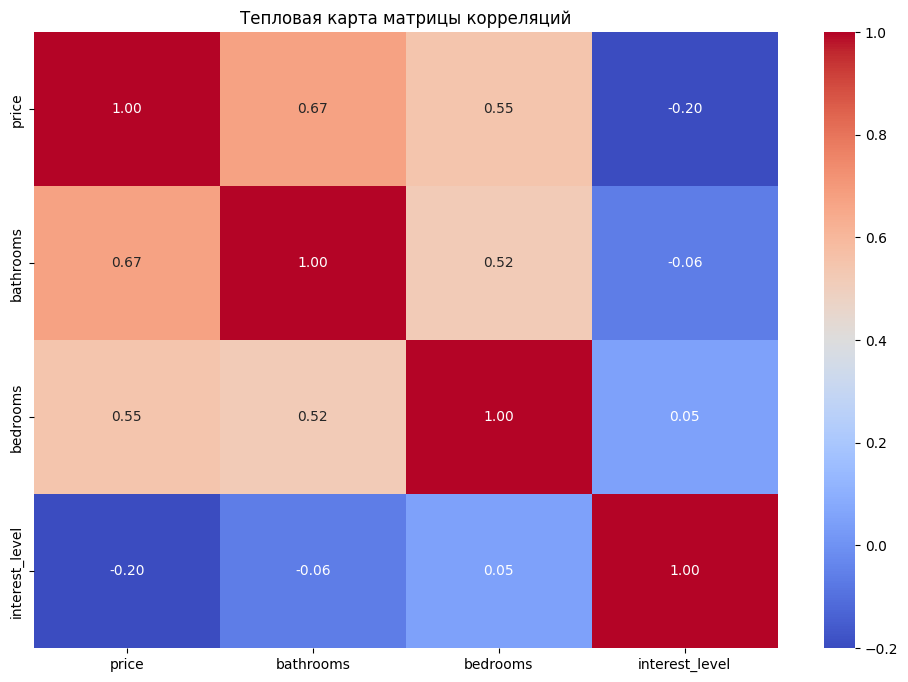

In [283]:
corr_matrix = df_selected.corr()

# Построим тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Тепловая карта матрицы корреляций')
plt.show()

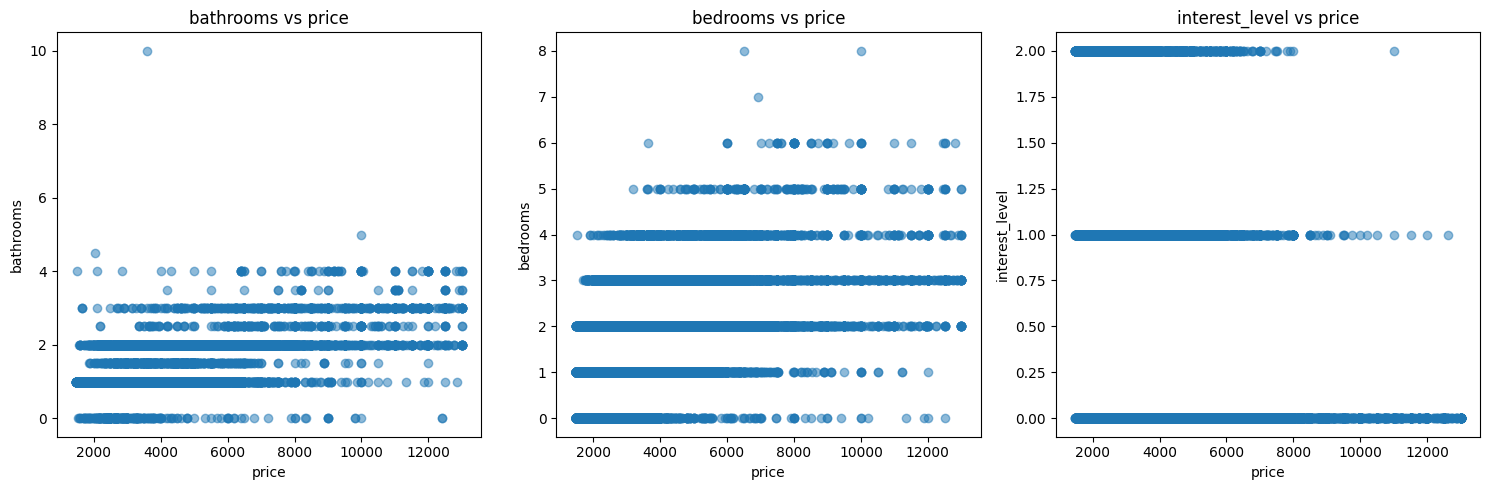

In [284]:
features = ['bathrooms', 'bedrooms', 'interest_level']  # замените или добавьте нужные признаки
target = 'price'  # замените на название вашей целевой переменной

plt.figure(figsize=(15, 5))

for i, feature in enumerate(features, 1):
    plt.subplot(1, 3, i)
    plt.scatter(df_selected[target], df_selected[feature], alpha=0.5)
    plt.xlabel(target)
    plt.ylabel(feature)
    plt.title(f'{feature} vs {target}')

plt.tight_layout()
plt.show()

# 4.Creating features

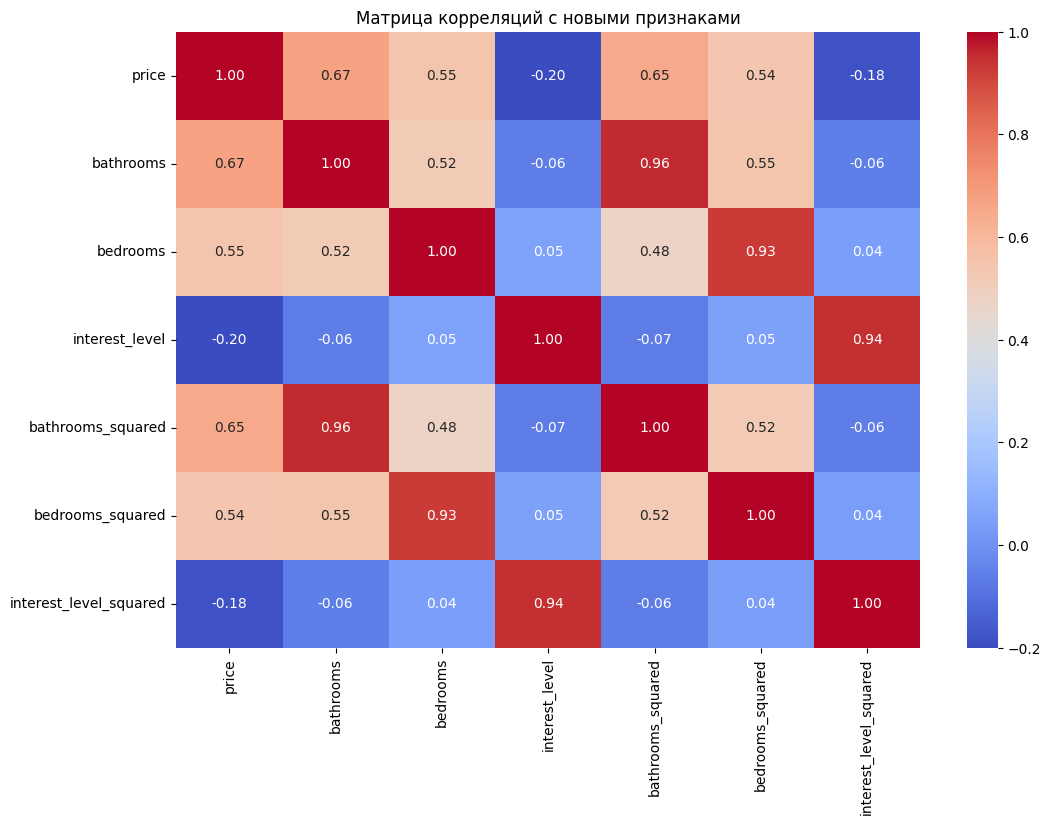

price                     1.000000
bathrooms                 0.671943
bathrooms_squared         0.648486
bedrooms                  0.545948
bedrooms_squared          0.543406
interest_level_squared   -0.182672
interest_level           -0.200111
Name: price, dtype: float64


In [285]:
df_selected['bathrooms_squared'] = df_selected['bathrooms'] ** 2
df_selected['bedrooms_squared'] = df_selected['bedrooms'] ** 2
df_selected['interest_level_squared'] = df_selected['interest_level'] ** 2

# Построение матрицы корреляции
corr_matrix = df_selected.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Матрица корреляций с новыми признаками')
plt.show()

# Анализ: сравните значения корреляции новых признаков с целевой переменной
target_corr = corr_matrix['price'].sort_values(ascending=False)
print(target_corr)

In [286]:
X_train = df_selected[['bathrooms', "bedrooms"]]

y_train = df_selected["price"]

## Read tests and train data

In [287]:
df_test = pd.read_json("test.json")
df_test.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address'],
      dtype='str')

Model fit

In [288]:
poly = PolynomialFeatures(degree = 10)

In [289]:
X_test = df_test[['bathrooms', 'bedrooms']]
y_test = df_test['price']
X_test

,bathrooms,bedrooms
0,1.0,1
1,1.0,2
2,1.0,0
3,1.0,2
5,1.0,1
...,...,...
124003,1.0,1
124005,1.0,2
124006,1.0,0
124007,2.0,2


In [290]:
y_test

0         2950
1         2850
2         2295
3         2900
5         3254
          ... 
124003    1700
124005    4195
124006    2400
124007    6895
124010    4695
Name: price, Length: 74659, dtype: int64

In [291]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [292]:
X_test_poly

array([[1.0000e+00, 1.0000e+00, 1.0000e+00, ..., 1.0000e+00, 1.0000e+00,
        1.0000e+00],
       [1.0000e+00, 1.0000e+00, 2.0000e+00, ..., 2.5600e+02, 5.1200e+02,
        1.0240e+03],
       [1.0000e+00, 1.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       ...,
       [1.0000e+00, 1.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [1.0000e+00, 2.0000e+00, 2.0000e+00, ..., 1.0240e+03, 1.0240e+03,
        1.0240e+03],
       [1.0000e+00, 1.0000e+00, 3.0000e+00, ..., 6.5610e+03, 1.9683e+04,
        5.9049e+04]], shape=(74659, 66))

# 5. Model training

In [293]:
result_MAE = pd.DataFrame(columns = ["model", "train", "test"])
result_RMSE = pd.DataFrame(columns = ["model", "train", "test"])

In [294]:
result_MAE

,model,train,test


LinearRegression

In [295]:
regression = LinearRegression()

In [296]:
print(X_train_poly.shape)

(48379, 66)


In [297]:
regression.fit(X_train_poly, y_train)
train_preds = regression.predict(X_train_poly)
test_preds = regression.predict(X_test_poly)

In [298]:
print(train_preds)

[3038.83971248 3201.84634836 3201.84634836 ... 3038.83971248 3201.84634836
 3885.19055775]


In [299]:
print(test_preds)

[3038.83971248 3201.84634836 2478.71489181 ... 2478.71489181 5405.15957753
 3885.19055775]


In [300]:
train_mae = mean_absolute_error(y_train, train_preds)
test_mae = mean_absolute_error(y_test, test_preds)

In [301]:
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

In [302]:
result_MAE.loc[len(result_MAE)] = {
    'model': 'linear_regression',
    'train': train_mae,
    'test': test_mae
}

In [303]:
result_MAE

,model,train,test
0,linear_regression,756.0403,1.448888e+16


In [304]:
result_RMSE.loc[len(result_RMSE)] = {
    'model': 'linear_regression',
    'train': train_rmse,
    'test': test_rmse
}

In [305]:
result_RMSE

,model,train,test
0,linear_regression,1077.566356,3.958913e+18


DEcision tree

In [ ]:
# Обучаем модель
tree_model = DecisionTreeRegressor(random_state=21)
tree_model.fit(X_train, y_train)

# Предсказываем
tree_train_preds = tree_model.predict(X_train)
tree_test_preds = tree_model.predict(X_test)

# Вычисляем метрики
tree_train_mae = mean_absolute_error(y_train, tree_train_preds)
tree_test_mae = mean_absolute_error(y_test, tree_test_preds)

tree_train_rmse = np.sqrt(mean_squared_error(y_train, tree_train_preds))
tree_test_rmse = np.sqrt(mean_squared_error(y_test, tree_test_preds))

# Вставляем результаты в таблицы
result_MAE.loc[len(result_MAE)] = {
    'model': 'decision_tree',
    'train': tree_train_mae,
    'test': tree_test_mae
}

result_RMSE.loc[len(result_RMSE)] = {
    'model': 'decision_tree',
    'train': tree_train_rmse,
    'test': tree_test_rmse
}

In [307]:
result_RMSE

,model,train,test
0,linear_regression,1077.566356,3.958913e+18
1,decision_tree,1077.483596,9.589261e+03


In [308]:
result_MAE

,model,train,test
0,linear_regression,756.040300,1.448888e+16
1,decision_tree,756.044735,9.535922e+02


Naive model

In [309]:
y_train

4         2400
6         3800
9         3495
10        3000
15        2795
          ... 
124000    2800
124002    2395
124004    1850
124008    4195
124009    4280
Name: price, Length: 48379, dtype: int64

In [ ]:
mean_train = y_train.mean()
median_train = y_train.median()

In [311]:
print(mean_train)

3538.6368879059096


In [312]:
mean_test = y_test.mean()
median_test = y_test.median()

In [313]:
print(median_test)

3150.0


In [314]:
y_test

0         2950
1         2850
2         2295
3         2900
5         3254
          ... 
124003    1700
124005    4195
124006    2400
124007    6895
124010    4695
Name: price, Length: 74659, dtype: int64

In [315]:
df_test

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address
0,1.0,1,79780be1514f645d7e6be99a3de696c5,2016-06-11 05:29:41,Large with awesome terrace--accessible via bed...,Suffolk Street,"[Elevator, Laundry in Building, Laundry in Uni...",40.7185,7142618,-73.9865,b1b1852c416d78d7765d746cb1b8921f,[https://photos.renthop.com/2/7142618_1c45a2c8...,2950,99 Suffolk Street
1,1.0,2,0,2016-06-24 06:36:34,Prime Soho - between Bleecker and Houston - Ne...,Thompson Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7278,7210040,-74.0000,d0b5648017832b2427eeb9956d966a14,[https://photos.renthop.com/2/7210040_d824cc71...,2850,176 Thompson Street
2,1.0,0,0,2016-06-17 01:23:39,Spacious studio in Prime Location. Cleanbuildi...,Sullivan Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7260,7174566,-74.0026,e6472c7237327dd3903b3d6f6a94515a,[https://photos.renthop.com/2/7174566_ba3a35c5...,2295,115 Sullivan Street
3,1.0,2,f9c826104b91d868e69bd25746448c0c,2016-06-21 05:06:02,For immediate access call Bryan.<br /><br />Bo...,Jones Street,"[Hardwood Floors, Dogs Allowed, Cats Allowed]",40.7321,7191391,-74.0028,41735645e0f8f13993c42894023f8e58,[https://photos.renthop.com/2/7191391_8c2f2d49...,2900,23 Jones Street
5,1.0,1,81062936e12ee5fa6cd2b965698e17d5,2016-06-16 07:24:27,Beautiful TRUE 1 bedroom in a luxury building ...,Exchange Place,"[Roof Deck, Doorman, Elevator, Fitness Center,...",40.7054,7171695,-74.0095,a742cf7dd3b2627d83417bc3a1b3ec96,[https://photos.renthop.com/2/7171695_089ffee2...,3254,20 Exchange Place
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124003,1.0,1,bd863d28a6b119ac3bc72d5f27b07f24,2016-04-26 16:09:55,BRAND NEW TO MARKET 1BDR \r107TH AND LEXINGTON...,150 EAST 107TH STREET,[],40.7925,6928108,-73.9454,453d46f8113e1f2c730c2ee5a4469c71,[https://photos.renthop.com/2/6928108_231eb983...,1700,158 EAST 107TH STREET
124005,1.0,2,9174b75c0cd978eb0e5aa93afbad754b,2016-04-21 05:06:19,Convertible 2BR apartment features a brand new...,E 33rd St.,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7456,6906674,-73.9797,2983e45f7e0ad87d677dacd13e362785,[https://photos.renthop.com/2/6906674_9fe899a8...,4195,141 E 33rd St.
124006,1.0,0,0,2016-04-20 01:31:52,"Let's get you in to see this $2,400/mo, recent...",Lexington Avenue,"[Dogs Allowed, Cats Allowed]",40.7416,6897967,-73.9829,e6472c7237327dd3903b3d6f6a94515a,[],2400,95 Lexington Avenue
124007,2.0,2,c90c010e5505365676538e64d02aa1e0,2016-04-08 02:26:45,CooperCooper.com :: Web ID #171357; Access 100...,Park Avenue,"[Doorman, Elevator, Cats Allowed, Dogs Allowed]",40.7485,6842183,-73.9800,6e5c10246156ae5bdcd9b487ca99d96a,[https://photos.renthop.com/2/6842183_b1fe51f4...,6895,41 Park Avenue


In [316]:
df_train = X_train.copy()
df_train['price_mean_pred'] = mean_train
df_train['price_median_pred'] = median_train
df_train

,bathrooms,bedrooms,price_mean_pred,price_median_pred
4,1.0,1,3538.636888,3150.0
6,1.0,2,3538.636888,3150.0
9,1.0,2,3538.636888,3150.0
10,1.5,3,3538.636888,3150.0
15,1.0,0,3538.636888,3150.0
...,...,...,...,...
124000,1.0,3,3538.636888,3150.0
124002,1.0,2,3538.636888,3150.0
124004,1.0,1,3538.636888,3150.0
124008,1.0,2,3538.636888,3150.0


In [317]:
df_test = X_test.copy()
df_test['price_mean_pred'] = mean_test
df_test['price_median_pred'] = median_test
df_test

,bathrooms,bedrooms,price_mean_pred,price_median_pred
0,1.0,1,3749.032829,3150.0
1,1.0,2,3749.032829,3150.0
2,1.0,0,3749.032829,3150.0
3,1.0,2,3749.032829,3150.0
5,1.0,1,3749.032829,3150.0
...,...,...,...,...
124003,1.0,1,3749.032829,3150.0
124005,1.0,2,3749.032829,3150.0
124006,1.0,0,3749.032829,3150.0
124007,2.0,2,3749.032829,3150.0


In [318]:
train_mae_mean = mean_absolute_error(y_train, df_train['price_mean_pred'])
test_mae_mean = mean_absolute_error(y_test, df_test['price_mean_pred'])

train_rmse_mean = np.sqrt(mean_squared_error(y_train, df_train['price_mean_pred']))
test_rmse_mean = np.sqrt(mean_squared_error(y_test, df_test['price_mean_pred']))

In [319]:
train_mae_median = mean_absolute_error(y_train, df_train['price_median_pred'])
test_mae_median = mean_absolute_error(y_test, df_test['price_median_pred'])

train_rmse_median = np.sqrt(mean_squared_error(y_train, df_train['price_median_pred']))
test_rmse_median = np.sqrt(mean_squared_error(y_test, df_test['price_median_pred']))

In [320]:
result_MAE.loc[len(result_MAE)] = {
    'model': 'naive_mean',
    'train': train_mae_mean,
    'test': test_mae_mean
}
result_RMSE.loc[len(result_RMSE)] = {
    'model': 'naive_mean',
    'train': train_rmse_mean,
    'test': test_rmse_mean
}

In [321]:
result_MAE.loc[len(result_MAE)] = {
    'model': 'naive_median',
    'train': train_mae_median,
    'test': test_mae_median
}
result_RMSE.loc[len(result_RMSE)] = {
    'model': 'naive_median',
    'train': train_rmse_median,
    'test': test_rmse_median
}

In [322]:
result_MAE

,model,train,test
0,linear_regression,756.040300,1.448888e+16
1,decision_tree,756.044735,9.535922e+02
2,naive_mean,1139.192515,1.440961e+03
3,naive_median,1086.210505,1.322641e+03


In [323]:
result_RMSE

,model,train,test
0,linear_regression,1077.566356,3.958913e+18
1,decision_tree,1077.483596,9.589261e+03
2,naive_mean,1597.646655,9.713027e+03
3,naive_median,1644.236439,9.731481e+03


In [324]:
best_mae_row = result_MAE.loc[result_MAE['train'].idxmin()]
print("Лучшая модель по MAE (train):")
print(best_mae_row)

Лучшая модель по MAE (train):
model      linear_regression
train               756.0403
test     14488881545383084.0
Name: 0, dtype: object


In [325]:
best_mae_test_row = result_MAE.loc[result_MAE['test'].idxmin()]
print("Лучшая модель по MAE (test):")
print(best_mae_test_row)

Лучшая модель по MAE (test):
model    decision_tree
train       756.044735
test        953.592155
Name: 1, dtype: object


In [326]:
best_rmse_row = result_RMSE.loc[result_RMSE['train'].idxmin()]
print("Лучшая модель по RMSE (train):")
print(best_rmse_row)

Лучшая модель по RMSE (train):
model    decision_tree
train      1077.483596
test       9589.260857
Name: 1, dtype: object


In [327]:
best_rmse_test_row = result_RMSE.loc[result_RMSE['test'].idxmin()]
print("Лучшая модель по RMSE (test):")
print(best_rmse_test_row)

Лучшая модель по RMSE (test):
model    decision_tree
train      1077.483596
test       9589.260857
Name: 1, dtype: object
